# Potential Wrappers

galpy's wrapper potentials modify existing potentials by adding time dependence,
rotation, tilting, or amplitude modulation. This notebook demonstrates the most
commonly used wrappers.

For basic potential usage, see the [Introduction to Potentials](introduction.ipynb).

In [1]:
%matplotlib inline
import numpy
from matplotlib import pyplot as plt
from galpy import potential
from galpy.potential import (
    MWPotential2014,
    SoftenedNeedleBarPotential,
    DehnenSmoothWrapperPotential,
    SolidBodyRotationWrapperPotential,
    RotateAndTiltWrapperPotential,
    GaussianAmplitudeWrapperPotential,
    TimeDependentAmplitudeWrapperPotential,
    LogarithmicHaloPotential,
    MiyamotoNagaiPotential,
)
from galpy.orbit import Orbit
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Growing a bar with DehnenSmoothWrapperPotential

A common use case is to smoothly grow a bar potential over some time period.
`DehnenSmoothWrapperPotential` multiplies a potential by a smooth function that
transitions from 0 to 1. This can be used to smoothly grow any potential from zero to its full amplitude. Use `decay=True` to instead smoothly turn a potential off.

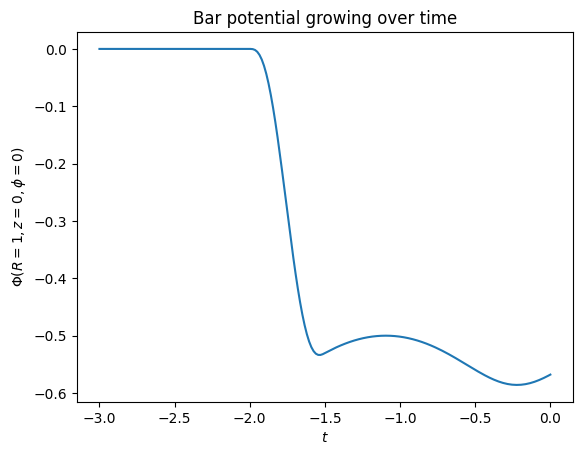

In [2]:
# Create a bar potential (SoftenedNeedleBarPotential does not have built-in smoothing)
bar = SoftenedNeedleBarPotential(normalize=0.05)

# Wrap it with a smooth growth function
bar_grown = DehnenSmoothWrapperPotential(pot=bar, tform=-2.0, tsteady=0.5)

# Show the amplitude over time
ts = numpy.linspace(-3.0, 0.0, 201)
amps = [bar_grown(1.0, 0.0, phi=0.0, t=t) for t in ts]
plt.plot(ts, amps)
plt.xlabel(r"$t$")
plt.ylabel(r"$\Phi(R=1, z=0, \phi=0)$")
plt.title("Bar potential growing over time");

## SolidBodyRotationWrapperPotential

This wrapper rotates a potential at a constant angular velocity. This is useful
for adding a rotating bar to an axisymmetric background.

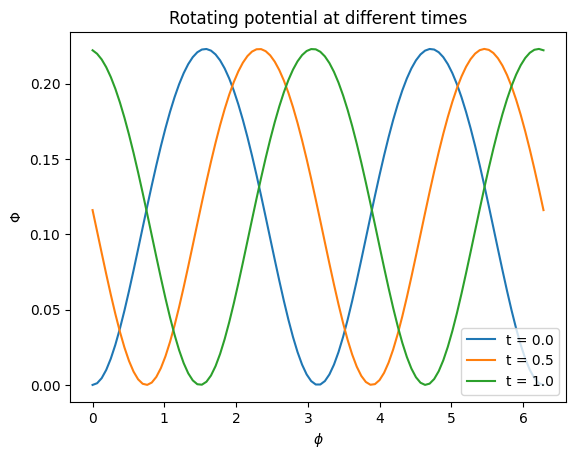

In [3]:
# A triaxial logarithmic halo potential, made to rotate
lp = LogarithmicHaloPotential(normalize=1.0, b=0.8, q=0.9)
lp_rot = SolidBodyRotationWrapperPotential(pot=lp, omega=1.5)

# Evaluate at different times to see the rotation
phis = numpy.linspace(0, 2 * numpy.pi, 100)
for t in [0.0, 0.5, 1.0]:
    vals = [lp_rot(1.0, 0.0, phi=phi, t=t) for phi in phis]
    plt.plot(phis, vals, label=f"t = {t:.1f}")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\Phi$")
plt.legend()
plt.title("Rotating potential at different times");

## RotateAndTiltWrapperPotential

This wrapper rotates and tilts a potential with respect to the default
coordinate system. This is useful for, e.g., modeling a tilted dark-matter halo.

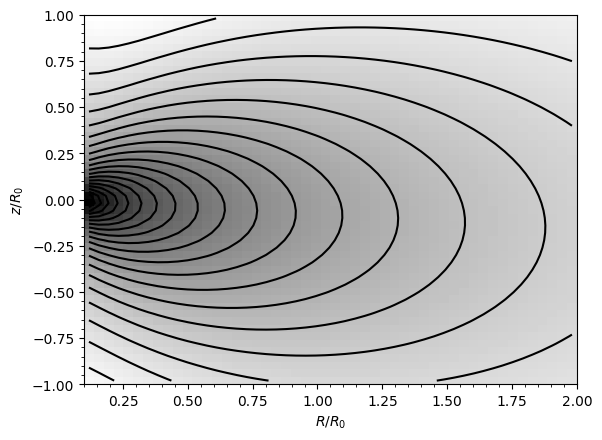

In [4]:
# Tilt a flattened logarithmic potential by 30 degrees
lp_flat = LogarithmicHaloPotential(normalize=1.0, q=0.7)
lp_tilted = RotateAndTiltWrapperPotential(
    pot=lp_flat, zvec=[0.0, numpy.sin(numpy.pi / 6), numpy.cos(numpy.pi / 6)]
)

# Compare densities in the (x, z) plane
potential.plotDensities(
    lp_tilted,
    rmin=0.1,
    rmax=2.0,
    zmin=-1.0,
    zmax=1.0,
    nrs=50,
    nzs=50,
    log=True,
    phi=0.2,
);

## GaussianAmplitudeWrapperPotential

Multiplies a potential by a Gaussian in time, useful for transient perturbations:

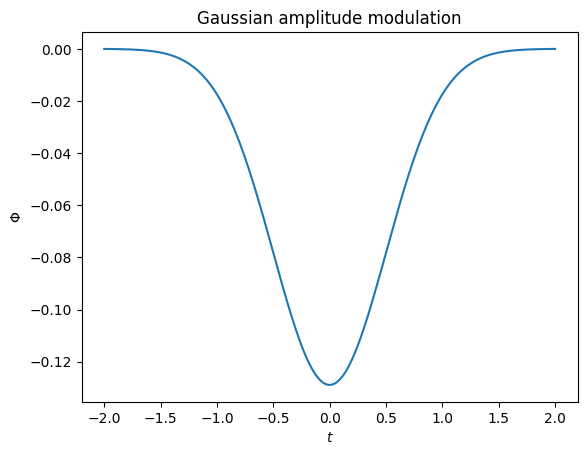

In [5]:
disk = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=0.1)
transient = GaussianAmplitudeWrapperPotential(pot=disk, to=0.0, sigma=0.5)

ts = numpy.linspace(-2.0, 2.0, 201)
amps = [transient(1.0, 0.0, t=t) for t in ts]
plt.plot(ts, amps)
plt.xlabel(r"$t$")
plt.ylabel(r"$\Phi$")
plt.title("Gaussian amplitude modulation");

## TimeDependentAmplitudeWrapperPotential

The fully general `TimeDependentAmplitudeWrapperPotential` can modulate the amplitude
of any potential with an arbitrary function of time. This is useful for creating
custom time-dependent perturbations.

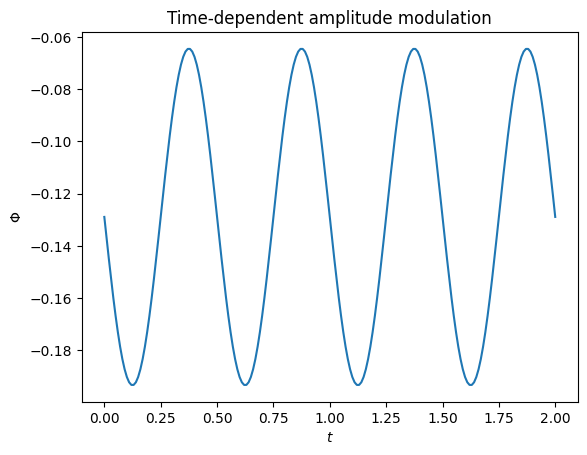

In [6]:
# Sinusoidal amplitude modulation
disk = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=0.1)
oscillating = TimeDependentAmplitudeWrapperPotential(
    pot=disk, A=lambda t: 1.0 + 0.5 * numpy.sin(4.0 * numpy.pi * t)
)

ts = numpy.linspace(0.0, 2.0, 201)
amps = [oscillating(1.0, 0.0, t=t) for t in ts]
plt.plot(ts, amps)
plt.xlabel(r"$t$")
plt.ylabel(r"$\Phi$")
plt.title("Time-dependent amplitude modulation");

## Combining wrappers with background potentials

A typical use case: grow a rotating bar on top of an axisymmetric MW potential
and integrate an orbit:

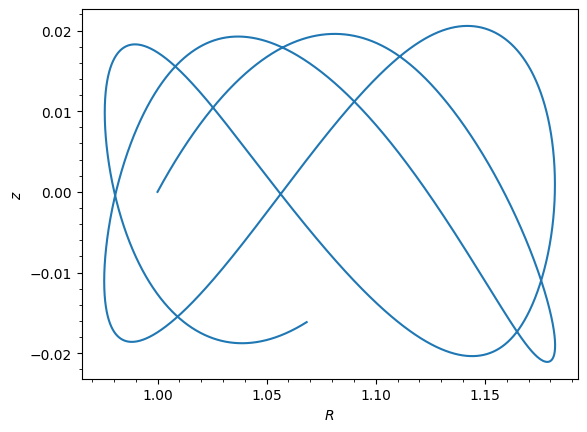

In [7]:
# Axisymmetric background
bg = MWPotential2014

# Bar potential, smoothly grown using DehnenSmoothWrapperPotential
bar = SoftenedNeedleBarPotential(normalize=0.05)
bar_smooth = DehnenSmoothWrapperPotential(pot=bar, tform=-2.0, tsteady=0.5)

# Make the bar rotate
bar_rotating = SolidBodyRotationWrapperPotential(pot=bar_smooth, omega=1.8)

# Full potential = background + rotating bar
full_pot = bg + bar_rotating

# Integrate an orbit
o = Orbit([1.0, 0.1, 1.1, 0.0, 0.05, 0.0])
ts = numpy.linspace(0.0, 10.0, 10001)
o.integrate(ts, full_pot)
o.plot();

<div class="alert alert-warning">

**Warning:** When wrapping a potential that has physical outputs turned on, the wrapper
object inherits the units of the wrapped potential and automatically turns them on,
even when you do not explicitly set `ro=` and `vo=`.

</div>